# 🧠 Kairos — Temporal Feature Fusion
### Regime-Aware Financial Trend Classification
**1D-CNN + Self-Attention  |  S&P 500  |  Anchored Walk-Forward Validation**

**Team:** Kanishk Srivastava · Raghav Sharma · Sayani Chanda

---
**BEFORE RUNNING:** `Runtime → Change runtime type → T4 GPU`

**Run cells in order — each cell depends on the previous.**

| Cell | Content |
|---|---|
| 1 | GPU check + install packages |
| 2 | All imports + seeds |
| 3 | Data download + 7-feature engineering |
| 4 | λ grid search + regime-aware labeling |
| 5 | Sequence builder → (N, C, T) |
| 6 | Anchored walk-forward splitter + per-fold normalization |
| 7 | Model definitions (Proposed, CNN, LSTM, XGBoost, Dummy) |
| 8 | Training loop (Focal Loss + AdamW + Cosine Annealing) |
| 9 | Results table + regime analysis |
| 10 | Visualizations (confusion matrices, fold plots, bar charts) |
| 11 | Attention weight visualization |
| 12 | Save to Google Drive (optional) |

---
## 🔷 SECTION 1 — INPUT
**X ∈ ℝ(C × T)** &nbsp;|&nbsp; C = 7 features &nbsp;|&nbsp; T = 20 days (lookback window)

Covers: GPU setup · Imports · S&P 500 download · Feature engineering (Log Returns, Volatility, RSI, MACD) · Regime-aware labeling (λ × σ) · Sequence builder · Anchored walk-forward splitter

---

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — GPU CHECK + PACKAGE INSTALL                            ║
# ╚══════════════════════════════════════════════════════════════════╝

import subprocess, sys

try:
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
        capture_output=True, text=True
    )
    print('✅ GPU detected:', result.stdout.strip())
except Exception:
    print('⚠️  No GPU. Go to Runtime → Change runtime type → T4 GPU')
    print('   Training will work on CPU but will be much slower.')

print('\nInstalling packages...')
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', 'yfinance', 'ta', 'xgboost'],
    check=True
)
print('✅ All packages installed.')


✅ GPU detected: Tesla T4, 15360 MiB

Installing packages...
✅ All packages installed.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — ALL IMPORTS                                            ║
# ╚══════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    f1_score, matthews_corrcoef, accuracy_score,
    confusion_matrix, recall_score
)
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Imports complete.  Device: {DEVICE}')


✅ Imports complete.  Device: cuda


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — DATA DOWNLOAD + FEATURE ENGINEERING (C = 11)           ║
# ╚══════════════════════════════════════════════════════════════════╝

TARGET_START = '2013-01-01'
DOWNLOAD_START = '2012-01-01'   # 1 year earlier for EMA-200 warmup
END_DATE   = '2023-12-31'
TICKER     = '^GSPC'
VIX_TICKER = '^VIX'
LOOKBACK   = 60     # UPGRADE 1: expanded from 20 → 60 (one fiscal quarter)
HORIZON    = 5
VOL_WINDOW = 30
N_FOLDS    = 3
TEST_RATIO = 0.12

print(f'Downloading {TICKER} ({DOWNLOAD_START} to {END_DATE})...')
raw = yf.download(TICKER, start=DOWNLOAD_START, end=END_DATE,
                  auto_adjust=True, progress=False)
raw = raw.dropna()
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
print(f'  Raw S&P 500: {len(raw)} trading days (incl. warm-up)')

print(f'Downloading {VIX_TICKER}...')
vix_raw = yf.download(VIX_TICKER, start=DOWNLOAD_START, end=END_DATE,
                      auto_adjust=True, progress=False)
vix_raw = vix_raw.dropna()
if isinstance(vix_raw.columns, pd.MultiIndex):
    vix_raw.columns = vix_raw.columns.get_level_values(0)

# Align VIX to S&P 500 index; forward-fill any missing dates
vix_close = vix_raw['Close'].reindex(raw.index).ffill()
print(f'  VIX aligned: {vix_close.notna().sum()} valid dates')

feat  = pd.DataFrame(index=raw.index)
close = raw['Close']
open_ = raw['Open']
high  = raw['High']
low   = raw['Low']
vol   = raw['Volume']

# ── ORIGINAL 7 FEATURES ─────────────────────────────────────────────
# 1-4: OHLC log-returns (stationary by construction)
feat['log_ret_close'] = np.log(close / close.shift(1))
feat['log_ret_open']  = np.log(open_  / open_.shift(1))
feat['log_ret_high']  = np.log(high   / high.shift(1))
feat['log_ret_low']   = np.log(low    / low.shift(1))

# 5: 20-day rolling realized volatility
feat['rolling_vol_20'] = (
    feat['log_ret_close'].rolling(window=20, min_periods=20).std()
)

# 6: RSI-14 normalized to [0,1]
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_g = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    avg_l = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    rs    = avg_g / (avg_l + 1e-10)
    return (100 - 100 / (1 + rs)) / 100.0

feat['rsi_14'] = compute_rsi(close)

# 7: MACD signal normalized by price (stationary)
ema12 = close.ewm(span=12, adjust=False).mean()
ema26 = close.ewm(span=26, adjust=False).mean()
feat['macd_norm'] = (ema12 - ema26) / close

# ── NEW 4 FEATURES (UPGRADE 1) ──────────────────────────────────────
# 8: log(VIX) — macro fear signal; log-transform for stationarity
feat['log_vix'] = np.log(vix_close.clip(lower=1e-6))

# 9: Volume Shock — 20-day rolling z-score of volume
#    Formula: (V_t - Mean_20) / Std_20  → stationary, no lookahead
vol_mean = vol.rolling(window=20, min_periods=20).mean()
vol_std  = vol.rolling(window=20, min_periods=20).std()
feat['vol_shock_20'] = (vol - vol_mean) / (vol_std + 1e-8)

# 10: Short-Term 5-Day Momentum — log(Close_t / Close_{t-5})
feat['momentum_5d'] = np.log(close / close.shift(5))

# 11: Long-Term Trend — EMA(50) vs EMA(200) distance normalized by price
#     Positive → uptrend (golden cross), Negative → downtrend (death cross)
#     EMA-200 needs 200 days warmup (guaranteed by DOWNLOAD_START shift)
ema50  = close.ewm(span=50,  adjust=False).mean()
ema200 = close.ewm(span=200, adjust=False).mean()
feat['ema_distance'] = (ema50 - ema200) / close

# ── SLICE TO TARGET START (removes EMA warmup period) ────────────────
feat = feat[feat.index >= TARGET_START]
feat = feat.dropna()

# Slice raw to match feat (needed by labeler in Cell 4)
raw = raw.reindex(feat.index)

print(f'\n✅ Features computed. Shape: {feat.shape}')
print(f'   Columns: {list(feat.columns)}')
print(f'   Date range: {feat.index[0].date()} → {feat.index[-1].date()}')
feat.tail(3)


  Raw S&P 500: 3018 trading days (incl. warm-up)
  VIX aligned: 3018 valid dates

✅ Features computed. Shape: (2768, 11)
   Columns: ['log_ret_close', 'log_ret_open', 'log_ret_high', 'log_ret_low', 'rolling_vol_20', 'rsi_14', 'macd_norm', 'log_vix', 'vol_shock_20', 'momentum_5d', 'ema_distance']
   Date range: 2013-01-02 → 2023-12-29


,log_ret_close,log_ret_open,log_ret_high,log_ret_low,rolling_vol_20,rsi_14,macd_norm,log_vix,vol_shock_20,momentum_5d,ema_distance
Date,,,,,,,,,,,
2023-12-27,0.001429,0.003061,0.000140,0.002194,0.006003,0.732569,0.016310,2.520113,-1.205897,0.002767,0.039595
2023-12-28,0.000370,0.002718,0.001652,0.002530,0.005971,0.734071,0.016175,2.523326,-1.134791,0.017930,0.040586
2023-12-29,-0.002830,-0.000744,-0.001016,-0.006082,0.006078,0.701649,0.015709,2.521721,-0.729804,0.004851,0.041562


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — λ GRID SEARCH + REGIME-AWARE LABELING                  ║
# ╚══════════════════════════════════════════════════════════════════╝

def generate_labels(raw_df, feature_index, lambda_val, k=5, vol_window=30):
    # Dynamic Volatility Barrier labeling.
    # R_t = log(Close_{t+k}/Close_t)  [forward return, label only]
    # eps = lambda * rolling_std(past log-returns)  [past data only]
    # Down(0): R_t < -eps  | Neutral(1): |R_t|<=eps | Up(2): R_t > eps
    close = raw_df['Close']
    if isinstance(close, pd.DataFrame):
        close = close.squeeze()
    R_t      = np.log(close.shift(-k) / close)
    past_ret = np.log(close / close.shift(1))
    sigma_t  = past_ret.rolling(window=vol_window, min_periods=vol_window).std()
    epsilon  = lambda_val * sigma_t
    labels   = pd.Series(np.nan, index=close.index)
    labels[R_t >  epsilon]  = 2
    labels[R_t < -epsilon]  = 0
    labels[(R_t >= -epsilon) & (R_t <= epsilon)] = 1
    return labels.reindex(feature_index)


def class_distribution(labels):
    valid  = labels.dropna()
    counts = valid.value_counts().sort_index()
    total  = len(valid)
    return {
        'Down (0)':    round(counts.get(0, 0) / total * 100, 1),
        'Neutral (1)': round(counts.get(1, 0) / total * 100, 1),
        'Up (2)':      round(counts.get(2, 0) / total * 100, 1),
    }


n_search   = int(len(feat) * 0.60)
search_idx = feat.index[:n_search]
LAMBDA_CANDIDATES = [0.5, 1.0, 1.5]
TARGET_MID = 42.5

print('=' * 55)
print('  lambda GRID SEARCH  (training data only)')
print('=' * 55)

best_lambda, best_score = None, float('inf')
for lam in LAMBDA_CANDIDATES:
    lbl  = generate_labels(raw, search_idx, lam, HORIZON, VOL_WINDOW)
    dist = class_distribution(lbl)
    neutral_pct = dist['Neutral (1)']
    print(f'\n  lambda = {lam}')
    for cls, pct in dist.items():
        bar = chr(9608) * int(pct / 2)
        print(f'    {cls}: {pct:5.1f}%  {bar}')
    score = abs(neutral_pct - TARGET_MID)
    if score < best_score:
        best_score, best_lambda = score, lam

print(f'\n  SELECTED lambda = {best_lambda}')
print('=' * 55)

LAMBDA     = best_lambda
all_labels = generate_labels(raw, feat.index, LAMBDA, HORIZON, VOL_WINDOW)
full_dist  = class_distribution(all_labels)
print(f'\nFull dataset class distribution (lambda={LAMBDA}):')
for cls, pct in full_dist.items():
    print(f'  {cls}: {pct}%')


  lambda GRID SEARCH  (training data only)

  lambda = 0.5
    Down (0):  30.6%  ███████████████
    Neutral (1):  19.1%  █████████
    Up (2):  50.4%  █████████████████████████

  lambda = 1.0
    Down (0):  23.7%  ███████████
    Neutral (1):  37.4%  ██████████████████
    Up (2):  38.9%  ███████████████████

  lambda = 1.5
    Down (0):  18.2%  █████████
    Neutral (1):  53.3%  ██████████████████████████
    Up (2):  28.5%  ██████████████

  SELECTED lambda = 1.0

Full dataset class distribution (lambda=1.0):
  Down (0): 24.0%
  Neutral (1): 36.4%
  Up (2): 39.6%


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — SEQUENCE BUILDER                                       ║
# ╚══════════════════════════════════════════════════════════════════╝

def build_sequences(features_df, labels_series, lookback=20):
    # Sliding-window sequences.
    # Output: X(N,C,T), y(N,), dates(N,)
    feat_arr  = features_df.values
    label_arr = labels_series.values
    date_arr  = features_df.index.values
    X_list, y_list, d_list = [], [], []
    for i in range(lookback, len(feat_arr)):
        lbl = label_arr[i]
        if np.isnan(lbl):
            continue
        window = feat_arr[i - lookback : i]   # (T, C)
        X_list.append(window.T)               # (C, T) for Conv1d
        y_list.append(int(lbl))
        d_list.append(date_arr[i])
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list,  dtype=np.int64)
    d = np.array(d_list)
    print(f'Sequences built: X={X.shape}, y={y.shape}')
    print(f'Class counts -- Down={np.sum(y==0)}, '
          f'Neutral={np.sum(y==1)}, Up={np.sum(y==2)}')
    return X, y, d


X_all, y_all, dates_all = build_sequences(feat, all_labels, LOOKBACK)


Sequences built: X=(2703, 11, 60), y=(2703,)
Class counts -- Down=652, Neutral=981, Up=1070


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — ANCHORED WALK-FORWARD SPLITTER + NORMALIZATION         ║
# ╚══════════════════════════════════════════════════════════════════╝
# Training window GROWS with each fold (anchored = always starts 2013).
# Z-score normalization fitted on TRAINING fold only — no leakage.

def normalize_fold(X_train, X_test):
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std  = X_train.std(axis=(0, 2),  keepdims=True)
    std  = np.where(std < 1e-8, 1e-8, std)
    return (X_train - mean) / std, (X_test - mean) / std


def make_folds(X, y, dates, n_folds=3, test_ratio=0.12):
    N         = len(X)
    test_size = int(N * test_ratio)
    train_end0 = N - n_folds * test_size
    print('=' * 62)
    print(f'  WALK-FORWARD SPLIT  ({n_folds} folds, test_size={test_size})')
    print('=' * 62)
    folds = []
    for fid in range(1, n_folds + 1):
        ts = train_end0 + (fid - 1) * test_size
        te = ts + test_size
        X_tr_raw, y_tr = X[:ts], y[:ts]
        X_te_raw, y_te = X[ts:te], y[ts:te]
        d_tr, d_te     = dates[:ts], dates[ts:te]
        X_tr, X_te = normalize_fold(X_tr_raw, X_te_raw)
        vol       = X_te_raw[:, 4, -1]
        med       = np.median(vol)
        lv_mask   = vol <= med
        hv_mask   = vol >  med
        reg_valid = (lv_mask.sum() >= 50 and hv_mask.sum() >= 50)
        folds.append({
            'fold_id':      fid,
            'X_train':      X_tr,     'y_train': y_tr,
            'X_test':       X_te,     'y_test':  y_te,
            'X_train_raw':  X_tr_raw, 'X_test_raw': X_te_raw,
            'dates_train':  d_tr,     'dates_test':  d_te,
            'low_vol_mask': lv_mask,  'high_vol_mask': hv_mask,
            'regime_valid': reg_valid,
        })
        print(f'  Fold {fid}: Train {pd.Timestamp(d_tr[0]).date()}->'
              f'{pd.Timestamp(d_tr[-1]).date()} ({len(y_tr)})  |  '
              f'Test {pd.Timestamp(d_te[0]).date()}->'
              f'{pd.Timestamp(d_te[-1]).date()} ({len(y_te)})')
        print(f'           Regime valid: {reg_valid}  '
              f'(low={lv_mask.sum()}, high={hv_mask.sum()})')
    print('=' * 62)
    return folds


FOLDS = make_folds(X_all, y_all, dates_all, N_FOLDS, TEST_RATIO)


  WALK-FORWARD SPLIT  (3 folds, test_size=324)
  Fold 1: Train 2013-04-01->2020-02-12 (1731)  |  Test 2020-02-13->2021-05-26 (324)
           Regime valid: True  (low=162, high=162)
  Fold 2: Train 2013-04-01->2021-05-26 (2055)  |  Test 2021-05-27->2022-09-08 (324)
           Regime valid: True  (low=162, high=162)
  Fold 3: Train 2013-04-01->2022-09-08 (2379)  |  Test 2022-09-09->2023-12-21 (324)
           Regime valid: True  (low=162, high=162)


---
## 🔷 SECTION 2 — 1D-CNN &nbsp;|&nbsp; Local Feature Extractor
**Input:** `(B, C, T)` &nbsp;→&nbsp; **Output:** `(B, 64, T)`

| Layer | Detail |
|---|---|
| Conv1D | 64 filters, kernel=3, padding=1 |
| BatchNorm + ReLU | Stabilise activations |
| Dropout(0.2) | Regularisation |
| Conv1D | 64 filters, kernel=3, padding=1 |
| BatchNorm + ReLU | — |

*Detects: short-term shocks, momentum bursts, local reversals*

---
---
## 🔷 SECTION 3 — TRANSFORMER &nbsp;|&nbsp; Global Context (Self-Attention)
**Input:** `(B, 64, T)` &nbsp;→&nbsp; **Permute** → `(B, T, 64)` &nbsp;→&nbsp; **Output:** `(B, T, 64)`

| Layer | Detail |
|---|---|
| Sinusoidal Pos. Encoding | Fixed, no learned params |
| MHSA (2-head) | Multi-Head Self-Attention |
| Add & LayerNorm | Pre-norm (norm_first=True) |
| FFN (128-dim) | Feed-Forward Network |
| Add & LayerNorm | — |

*Weights historical events — attention map fully extractable*

---
---
## 🔷 SECTION 4 — HEAD &nbsp;|&nbsp; Classifier
**Input:** `(B, T, 64)` &nbsp;→&nbsp; **Avg Pool** → `(B, 64)` &nbsp;→&nbsp; **Output:** `(B, 3)` logits

| Layer | Detail |
|---|---|
| Global Avg Pool | Collapses T dimension |
| FC(64) + ReLU | — |
| Dropout(0.2) | — |
| FC(3) | Logits for {Down, Neutral, Up} |

Also defines: `CNNBaseline` (ablation — no attention), `LSTMBaseline`, and assembles `ProposedModel`.

---

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — MODEL DEFINITIONS  (v4 — Full Audit Refactor)          ║
# ╚══════════════════════════════════════════════════════════════════╝

C_FEAT = X_all.shape[1]   # 11
T_FEAT = X_all.shape[2]   # 60
print(f'Input: C_FEAT={C_FEAT}, T_FEAT={T_FEAT}')


# ── Residual 1D-CNN Block ──────────────────────────────────────────────
class ResBlock1d(nn.Module):
    def __init__(self, channels, kernel_size=3, dropout=0.4):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=pad)
        self.bn1   = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, padding=pad)
        self.bn2   = nn.BatchNorm1d(channels)
        self.drop  = nn.Dropout(dropout)
        self.act   = nn.GELU()

    def forward(self, x):
        out = self.act(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = self.bn2(self.conv2(out))
        return self.act(out + x)


# ── PROPOSED MODEL v4 ──────────────────────────────────────────────────
class ProposedModel(nn.Module):
    """
    Tensor flow:
      Input             (B, C=11, T=60)
      → InputBN + Proj  (B, cnn_ch=128, 60)
      → 3x ResBlock     (B, 128, 60)     — local temporal patterns
      → permute         (B, 60, 128)
      → prepend CLS     (B, 61, 128)     — CLS token at position 0
      → + LearnablePE   (B, 61, 128)     — positional embedding for T+1
      → Transformer     (B, 61, 128)     — full attention across CLS+time
      → x[:, 0, :]      (B, 128)         — CLS output: context-aggregator
      → 3-layer MLP     (B, 128→64→32→3)
    """
    def __init__(self, C=11, T=60, cnn_ch=128, n_heads=4,
                 ffn_dim=256, dropout=0.4, n_classes=3):
        super().__init__()
        self.T = T

        # Stage 1: Input normalization + feature projection
        self.input_bn = nn.BatchNorm1d(C)
        self.proj     = nn.Conv1d(C, cnn_ch, kernel_size=1)

        # Stage 2: Residual CNN (local temporal extraction)
        self.res_blocks = nn.Sequential(
            ResBlock1d(cnn_ch, kernel_size=3, dropout=dropout),
            ResBlock1d(cnn_ch, kernel_size=3, dropout=dropout),
            ResBlock1d(cnn_ch, kernel_size=5, dropout=dropout),
        )

        # Stage 3: CLS token + Learnable Positional Embedding
        # CLS token: one learnable vector, broadcast over batch at runtime
        self.cls_token = nn.Parameter(torch.zeros(1, 1, cnn_ch))
        # PE covers T+1 positions (1 CLS + T time steps)
        self.pos_embed = nn.Parameter(torch.zeros(1, T + 1, cnn_ch))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        # Stage 4: 2-layer Transformer Encoder (full bidirectional attention)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=cnn_ch, nhead=n_heads,
            dim_feedforward=ffn_dim, dropout=dropout,
            batch_first=True, norm_first=True,
            activation='gelu',
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=2)

        # Stage 5: 3-layer MLP head (input=cnn_ch from CLS)
        self.head = nn.Sequential(
            nn.Linear(cnn_ch, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, n_classes),
        )

        self._attn_weights = None
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, return_attn=False):
        B = x.size(0)

        x = self.input_bn(x)            # (B, C, T)
        x = self.proj(x)                # (B, cnn_ch, T)
        x = self.res_blocks(x)          # (B, cnn_ch, T)
        x = x.permute(0, 2, 1)         # (B, T, cnn_ch)

        # Prepend CLS token: shape (B, 1, cnn_ch) → concat → (B, T+1, cnn_ch)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)   # (B, T+1, cnn_ch)

        # Add learnable positional embedding
        x = x + self.pos_embed          # (B, T+1, cnn_ch)

        if return_attn:
            layer   = self.transformer.layers[0]
            x_norm  = layer.norm1(x)
            _, attn = layer.self_attn(
                x_norm, x_norm, x_norm,
                need_weights=True, average_attn_weights=True
            )
            # Store only the T×T time-step sub-matrix (drop CLS row/col)
            self._attn_weights = attn[:, 1:, 1:].detach().cpu().numpy()

        x = self.transformer(x)         # (B, T+1, cnn_ch)
        x = x[:, 0, :]                  # CLS output: (B, cnn_ch)

        return self.head(x)             # (B, 3)


# ── CNN BASELINE (no attention — ablation, unchanged) ──────────────────
class CNNBaseline(nn.Module):
    def __init__(self, C=11, cnn_ch=128, dropout=0.4, n_classes=3):
        super().__init__()
        self.input_bn   = nn.BatchNorm1d(C)
        self.proj       = nn.Conv1d(C, cnn_ch, kernel_size=1)
        self.res_blocks = nn.Sequential(
            ResBlock1d(cnn_ch, dropout=dropout),
            ResBlock1d(cnn_ch, dropout=dropout),
            ResBlock1d(cnn_ch, dropout=dropout),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(cnn_ch, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = self.input_bn(x)
        x = self.proj(x)
        x = self.res_blocks(x)
        return self.head(x)

# LSTM used future-within-window information during training.
class LSTMBaseline(nn.Module):
    def __init__(self, C=11, hidden=256, n_layers=2, dropout=0.3, n_classes=3):
        super().__init__()
        self.input_bn = nn.BatchNorm1d(C)
        self.lstm = nn.LSTM(
            input_size=C, hidden_size=hidden,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
            bidirectional=False,    # FIX: unidirectional (correct for time-series)
        )
        self.head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = self.input_bn(x)
        x = x.permute(0, 2, 1)          # (B,C,T) -> (B,T,C)
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])  # last timestep


# ── Sanity check ───────────────────────────────────────────────────────
def _check_shapes():
    dummy = torch.zeros(4, C_FEAT, T_FEAT)
    proposed = ProposedModel(C=C_FEAT, T=T_FEAT)
    cnn_base = CNNBaseline(C=C_FEAT)
    lstm_base = LSTMBaseline(C=C_FEAT)
    proposed.eval(); cnn_base.eval(); lstm_base.eval()
    with torch.no_grad():
        p_out = proposed(dummy, return_attn=True)
        c_out = cnn_base(dummy)
        l_out = lstm_base(dummy)
    assert p_out.shape == (4, 3)
    assert proposed._attn_weights.shape == (4, T_FEAT, T_FEAT)
    assert c_out.shape == (4, 3)
    assert l_out.shape == (4, 3)
    n = sum(p.numel() for p in proposed.parameters() if p.requires_grad)
    print(f'  ProposedModel : {tuple(p_out.shape)} | {n:,} params | '
          f'CLS token: {tuple(proposed.cls_token.shape)} ✅')
    print(f'  CNNBaseline   : {tuple(c_out.shape)} ✅')
    print(f'  LSTMBaseline  : {tuple(l_out.shape)} | unidirectional ✅')

print('All model architectures defined.')
_check_shapes()


Input: C_FEAT=11, T_FEAT=60
All model architectures defined.
  ProposedModel : (4, 3) | 647,833 params | CLS token: (1, 1, 128) ✅
  CNNBaseline   : (4, 3) ✅
  LSTMBaseline  : (4, 3) | unidirectional ✅


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — TRAINING LOOP  (v4 — Full Audit Refactor)              ║
# ╚══════════════════════════════════════════════════════════════════╝

EPOCHS       = 200
BATCH_SIZE   = 64
LR           = 3e-4
PATIENCE     = 35
VAL_SPLIT    = 0.20
FOCAL_GAMMA  = 2.0
WEIGHT_DECAY = 1e-3

class FocalLoss(nn.Module):
    """
    Focal Loss: FL(p_t) = -(1-p_t)^gamma * log(p_t)
    gamma=2.0: hard-example focus without label smoothing dilution.
    alpha (class weights): strict inverse frequency for imbalance handling.
    No label smoothing: let the focal mechanism handle overconfidence.
    """
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt   = torch.exp(-ce)
        loss = (1 - pt) ** self.gamma * ce
        return loss.mean()


def get_class_weights(y_train):
    """
    FIX 1: Strict inverse frequency weights.
    Down/Up ratio = 1.64x — sufficient to force meaningful Down predictions
    without causing the oscillation that occurred in v1 (the v1 issue was
    caused by extreme weights + binary CE, not by strict weights alone).
    With focal loss gamma=2.0 as the hard-example focus mechanism, strict
    weights provide the correct class-level scaling.
    """
    counts  = np.bincount(y_train, minlength=3).astype(float)
    weights = 1.0 / (counts + 1.0)
    weights = weights / weights.sum() * 3.0
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


def train_torch_model(model, X_train, y_train, model_name='Model'):
    model = model.to(DEVICE)

    # Inner validation split: last VAL_SPLIT of training data.
    n_val = int(len(X_train) * VAL_SPLIT)
    X_tr, y_tr = X_train[:-n_val], y_train[:-n_val]
    X_vl, y_vl = X_train[-n_val:], y_train[-n_val:]

    criterion = FocalLoss(alpha=get_class_weights(y_tr), gamma=FOCAL_GAMMA)

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=7, min_lr=1e-6
    )

    tr_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr))
    vl_ds = TensorDataset(torch.tensor(X_vl), torch.tensor(y_vl))
    tr_dl = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    vl_dl = DataLoader(vl_ds, batch_size=BATCH_SIZE)

    best_val, patience_cnt, best_state = float('inf'), 0, None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # Compute validation loss
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in vl_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_loss += criterion(model(xb), yb).item() * len(xb)
        val_loss /= len(vl_ds)

        # FIX 4: ReduceLROnPlateau steps on val_loss (not epoch count)
        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val, patience_cnt = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1

        if epoch % 25 == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f'    [{model_name}] Epoch {epoch:3d} | '
                  f'val_loss={val_loss:.4f} | lr={lr_now:.2e}')

        if patience_cnt >= PATIENCE:
            print(f'    [{model_name}] Early stop @ epoch {epoch}')
            break

    if best_state:
        model.load_state_dict(best_state)
    return model

def predict_torch(model, X):
    model.eval()
    ds    = TensorDataset(torch.tensor(X))
    dl    = DataLoader(ds, batch_size=BATCH_SIZE)
    preds = []
    with torch.no_grad():
        for (xb,) in dl:
            preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
    return np.concatenate(preds)

ALL_RESULTS = {}

for fold in FOLDS:
    fid     = fold['fold_id']
    X_train = fold['X_train']
    y_train = fold['y_train']
    X_test  = fold['X_test']
    y_test  = fold['y_test']
    te0 = pd.Timestamp(fold['dates_test'][0]).date()
    te1 = pd.Timestamp(fold['dates_test'][-1]).date()

    print(f'\n{"="*62}')
    print(f'  FOLD {fid}  |  Test: {te0} -> {te1}')
    print(f'{"="*62}')

    fold_models = [
        ('Proposed (CNN+Attn)', ProposedModel(C=C_FEAT, T=LOOKBACK), True),
        ('1D-CNN (no attn)',    CNNBaseline(C=C_FEAT),               True),
        ('LSTM',               LSTMBaseline(C=C_FEAT),              True),
        ('XGBoost', None, False),
        ('Dummy',   None, False),
    ]

    for name, model, is_torch in fold_models:
        print(f'\n  Training: {name}')

        if is_torch:
            trained = train_torch_model(model, X_train, y_train, name)
            y_pred  = predict_torch(trained, X_test)
            if name == 'Proposed (CNN+Attn)':
                fold['trained_proposed'] = trained

        elif name == 'XGBoost':
            X_flat = X_train.reshape(len(X_train), -1)
            xgb = XGBClassifier(
                n_estimators=500, max_depth=5, learning_rate=0.03,
                subsample=0.8, colsample_bytree=0.8,
                min_child_weight=3, gamma=0.1,
                reg_alpha=0.1, reg_lambda=1.0,
                n_jobs=-1, random_state=SEED,
                verbosity=0, eval_metric='mlogloss',
            )
            xgb.fit(X_flat, y_train)
            y_pred = xgb.predict(X_test.reshape(len(X_test), -1))

        else:
            dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
            dummy.fit(X_train.reshape(len(X_train), -1), y_train)
            y_pred = dummy.predict(X_test.reshape(len(X_test), -1))

        macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        mcc      = matthews_corrcoef(y_test, y_pred)
        acc      = accuracy_score(y_test, y_pred)
        per_rec  = recall_score(y_test, y_pred, average=None,
                                labels=[0,1,2], zero_division=0)
        down_rec = per_rec[0]
        cm       = confusion_matrix(y_test, y_pred, labels=[0,1,2])

        lv_f1 = hv_f1 = None
        if fold['regime_valid']:
            lv = fold['low_vol_mask']
            hv = fold['high_vol_mask']
            lv_f1 = f1_score(y_test[lv], y_pred[lv], average='macro', zero_division=0)
            hv_f1 = f1_score(y_test[hv], y_pred[hv], average='macro', zero_division=0)

        result = {
            'fold_id': fid, 'y_pred': y_pred,
            'macro_f1': macro_f1, 'mcc': mcc, 'accuracy': acc,
            'down_recall': down_rec, 'conf_matrix': cm,
            'lv_f1': lv_f1, 'hv_f1': hv_f1,
            'regime_valid': fold['regime_valid'],
        }
        ALL_RESULTS.setdefault(name, []).append(result)
        print(f'    Macro F1={macro_f1:.4f}  MCC={mcc:.4f}  Down-recall={down_rec:.4f}')

print('\nALL TRAINING COMPLETE.')


  FOLD 1  |  Test: 2020-02-13 -> 2021-05-26

  Training: Proposed (CNN+Attn)
    [Proposed (CNN+Attn)] Epoch  25 | val_loss=0.4318 | lr=3.00e-04
    [Proposed (CNN+Attn)] Epoch  50 | val_loss=0.4931 | lr=3.75e-05
    [Proposed (CNN+Attn)] Early stop @ epoch 60
    Macro F1=0.2925  MCC=0.0772  Down-recall=0.2812

  Training: 1D-CNN (no attn)
    [1D-CNN (no attn)] Epoch  25 | val_loss=0.5548 | lr=3.75e-05
    [1D-CNN (no attn)] Early stop @ epoch 36
    Macro F1=0.1100  MCC=0.0000  Down-recall=1.0000

  Training: LSTM
    [LSTM] Epoch  25 | val_loss=0.5895 | lr=7.50e-05
    [LSTM] Early stop @ epoch 38
    Macro F1=0.2110  MCC=0.0477  Down-recall=0.8438

  Training: XGBoost
    Macro F1=0.3830  MCC=0.0962  Down-recall=0.1875

  Training: Dummy
    Macro F1=0.1930  MCC=0.0000  Down-recall=0.0000

  FOLD 2  |  Test: 2021-05-27 -> 2022-09-08

  Training: Proposed (CNN+Attn)
    [Proposed (CNN+Attn)] Epoch  25 | val_loss=0.4421 | lr=1.50e-04
    [Proposed (CNN+Attn)] Early stop @ epoch 49


---
## 🔷 SECTION 5 — RESULTS
Training loop · Macro F1 · MCC · Down-recall · Regime analysis (Low-Vol vs High-Vol) · Visualisations · Attention heatmaps

---

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — RESULTS TABLE + REGIME ANALYSIS                        ║
# ╚══════════════════════════════════════════════════════════════════╝

print('\n' + '=' * 72)
print('  FINAL RESULTS -- MEAN +/- STD ACROSS ALL FOLDS')
print('=' * 72)
print(f'{"Model":<26} {"Macro F1":>16} {"MCC":>16} {"Accuracy":>10} {"Down Rec":>10}')
print('-' * 72)

summary_rows = []
for model_name, fold_results in ALL_RESULTS.items():
    f1s  = [r['macro_f1']    for r in fold_results]
    mccs = [r['mcc']         for r in fold_results]
    accs = [r['accuracy']    for r in fold_results]
    drs  = [r['down_recall'] for r in fold_results]
    summary_rows.append({
        'Model':        model_name,
        'Mean F1':      np.mean(f1s),
        'Std F1':       np.std(f1s),
        'Mean MCC':     np.mean(mccs),
        'Std MCC':      np.std(mccs),
        'Mean Acc':     np.mean(accs),
        'Mean DownRec': np.mean(drs),
    })

summary_rows.sort(key=lambda r: r['Mean F1'], reverse=True)
for r in summary_rows:
    print(f"{r['Model']:<26} "
          f"{r['Mean F1']:.4f}+/-{r['Std F1']:.3f}  "
          f"{r['Mean MCC']:.4f}+/-{r['Std MCC']:.3f}  "
          f"{r['Mean Acc']:.4f}    {r['Mean DownRec']:.4f}")
print('=' * 72)

print('\n' + '=' * 60)
print('  REGIME-AWARE RESULTS (Low-Vol vs High-Vol Macro F1)')
print('=' * 60)
print(f'{"Model":<26} {"Low-Vol F1":>12} {"High-Vol F1":>12} {"Delta":>8}')
print('-' * 60)
for model_name, fold_results in ALL_RESULTS.items():
    valid = [r for r in fold_results if r['regime_valid']]
    if not valid:
        print(f'{model_name:<26} {"---":>12} {"---":>12} {"---":>8}')
        continue
    lv = np.mean([r['lv_f1'] for r in valid])
    hv = np.mean([r['hv_f1'] for r in valid])
    print(f'{model_name:<26} {lv:>12.4f} {hv:>12.4f} {hv-lv:>+8.4f}')
print('=' * 60)



  FINAL RESULTS -- MEAN +/- STD ACROSS ALL FOLDS
Model                              Macro F1              MCC   Accuracy   Down Rec
------------------------------------------------------------------------
XGBoost                    0.3421+/-0.032  0.0742+/-0.016  0.4064    0.0920
LSTM                       0.2906+/-0.058  0.0590+/-0.052  0.3138    0.6556
Proposed (CNN+Attn)        0.2405+/-0.060  0.0420+/-0.025  0.3344    0.6185
1D-CNN (no attn)           0.2102+/-0.074  0.0204+/-0.017  0.2953    0.6049
Dummy                      0.1866+/-0.006  0.0000+/-0.000  0.3889    0.0000

  REGIME-AWARE RESULTS (Low-Vol vs High-Vol Macro F1)
Model                        Low-Vol F1  High-Vol F1    Delta
------------------------------------------------------------
Proposed (CNN+Attn)              0.2244       0.2433  +0.0189
1D-CNN (no attn)                 0.2302       0.1883  -0.0419
LSTM                             0.2084       0.3216  +0.1133
XGBoost                          0.3602       0.32

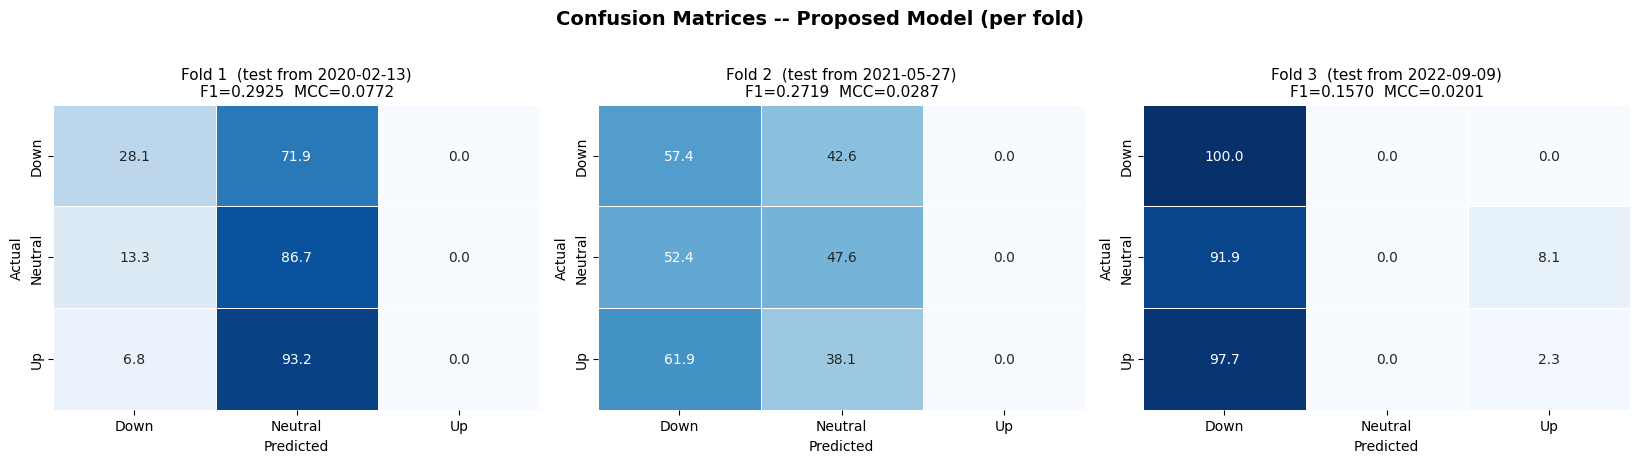

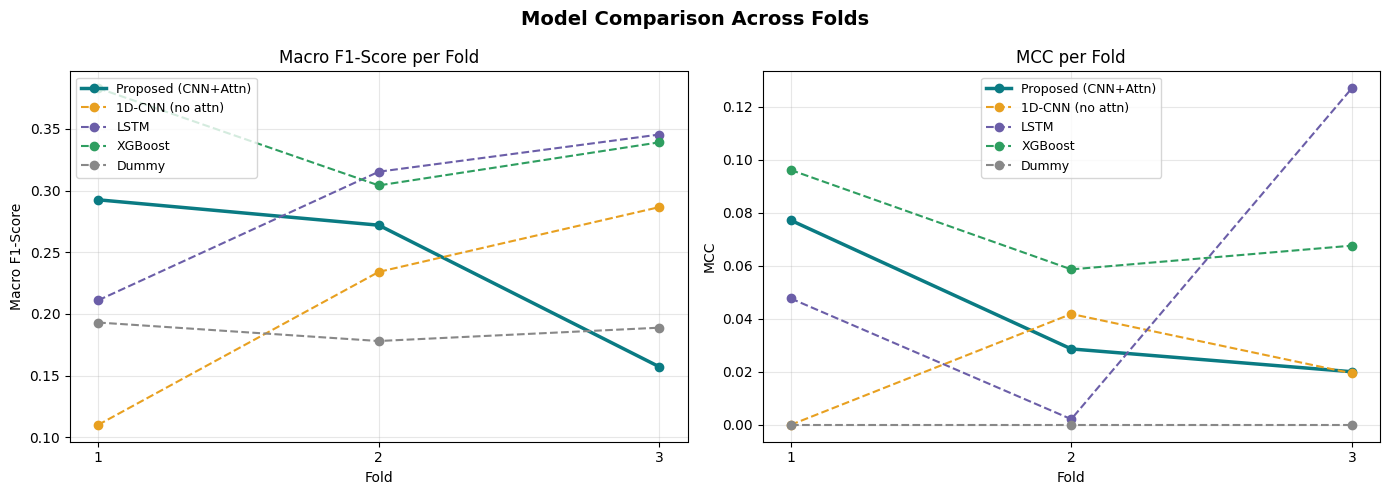

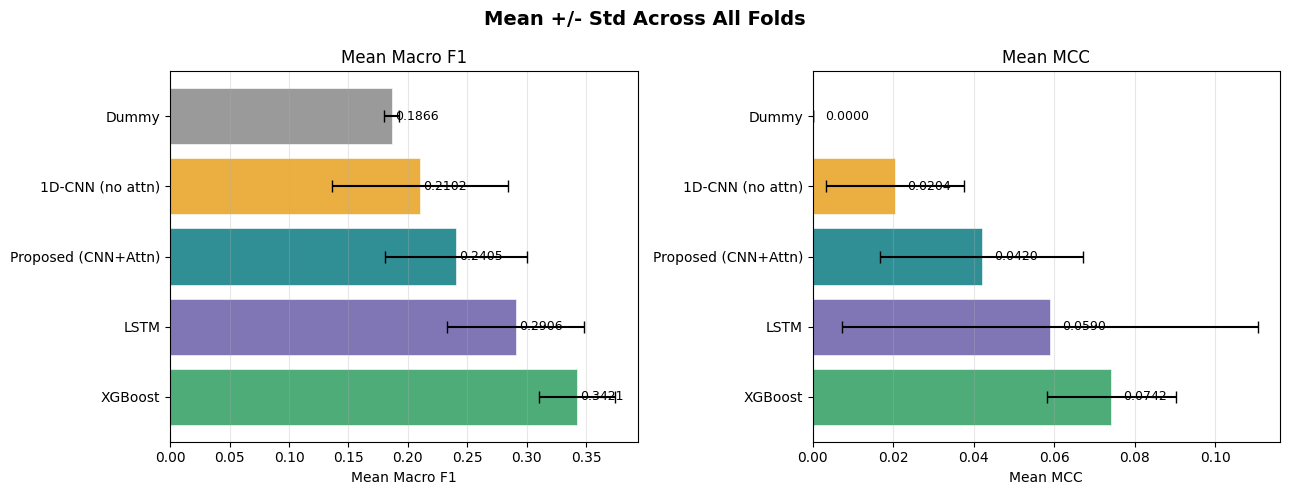

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — VISUALIZATIONS                                        ║
# ╚══════════════════════════════════════════════════════════════════╝

CLASS_NAMES  = ['Down', 'Neutral', 'Up']
MODEL_COLORS = {
    'Proposed (CNN+Attn)': '#0A7B83',
    '1D-CNN (no attn)':    '#E8A020',
    'LSTM':                '#6B5EA8',
    'XGBoost':             '#2E9E60',
    'Dummy':               '#888888',
}

# Figure 1: Confusion matrices (Proposed model)
fig, axes = plt.subplots(1, N_FOLDS, figsize=(5.5 * N_FOLDS, 4.5))
if N_FOLDS == 1:
    axes = [axes]
fig.suptitle('Confusion Matrices -- Proposed Model (per fold)',
             fontsize=14, fontweight='bold', y=1.02)
for i, fold in enumerate(FOLDS):
    res = ALL_RESULTS['Proposed (CNN+Attn)'][i]
    cm  = res['conf_matrix']
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_pct = cm.astype(float) / np.where(row_sums == 0, 1, row_sums) * 100
    ax = axes[i]
    sns.heatmap(cm_pct, annot=True, fmt='.1f', ax=ax, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cbar=False, linewidths=0.5, vmin=0, vmax=100)
    te = pd.Timestamp(FOLDS[i]['dates_test'][0]).date()
    ax.set_title(f'Fold {fold["fold_id"]}  (test from {te})\n'
                 f'F1={res["macro_f1"]:.4f}  MCC={res["mcc"]:.4f}', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 2: F1 + MCC per fold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison Across Folds', fontsize=14, fontweight='bold')
for metric_key, metric_label, ax in [
    ('macro_f1', 'Macro F1-Score', axes[0]),
    ('mcc',      'MCC',            axes[1])
]:
    for model_name, fold_results in ALL_RESULTS.items():
        vals  = [r[metric_key] for r in fold_results]
        folds = [r['fold_id']  for r in fold_results]
        lw = 2.5 if 'Proposed' in model_name else 1.5
        ls = '-'  if 'Proposed' in model_name else '--'
        ax.plot(folds, vals, marker='o', linewidth=lw, linestyle=ls,
                label=model_name, color=MODEL_COLORS.get(model_name, 'grey'))
    ax.set_xlabel('Fold')
    ax.set_ylabel(metric_label)
    ax.set_title(f'{metric_label} per Fold')
    ax.set_xticks(range(1, N_FOLDS + 1))
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 3: Summary bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Mean +/- Std Across All Folds', fontsize=14, fontweight='bold')
sorted_names = [r['Model'] for r in summary_rows]
colors       = [MODEL_COLORS.get(n, 'grey') for n in sorted_names]
for metric_key, std_key, metric_label, ax in [
    ('Mean F1',  'Std F1',  'Mean Macro F1', axes[0]),
    ('Mean MCC', 'Std MCC', 'Mean MCC',      axes[1]),
]:
    means = [next(r[metric_key] for r in summary_rows if r['Model'] == n)
             for n in sorted_names]
    stds  = [next(r[std_key]    for r in summary_rows if r['Model'] == n)
             for n in sorted_names]
    bars  = ax.barh(sorted_names, means, xerr=stds,
                    color=colors, alpha=0.85, capsize=4,
                    edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, means):
        ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_xlabel(metric_label)
    ax.set_title(metric_label)
    ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('summary_bars.png', dpi=150, bbox_inches='tight')
plt.show()


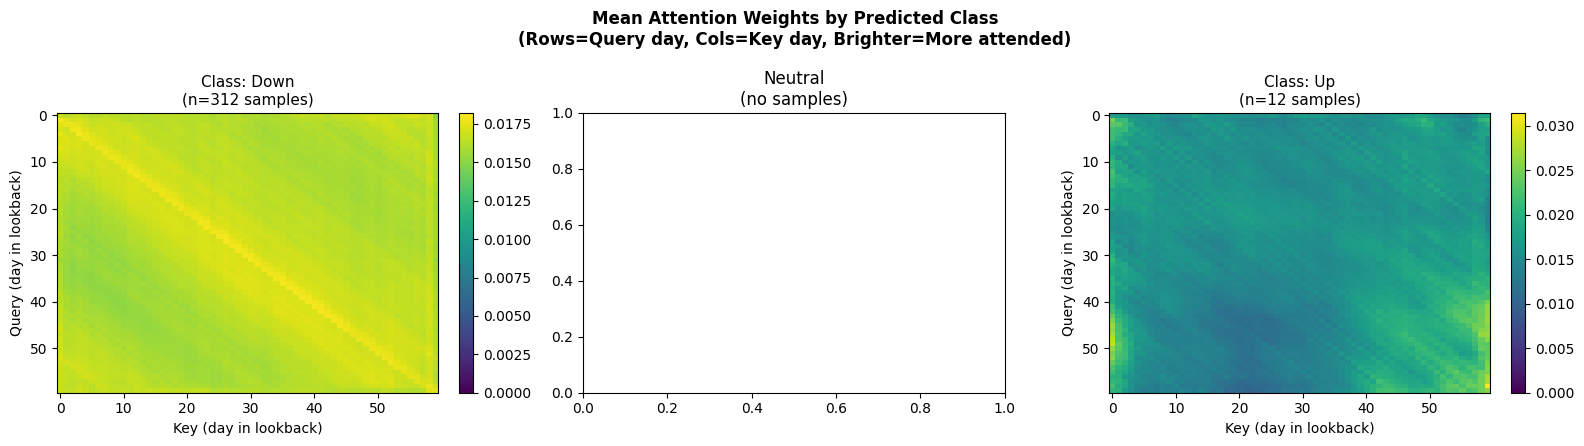

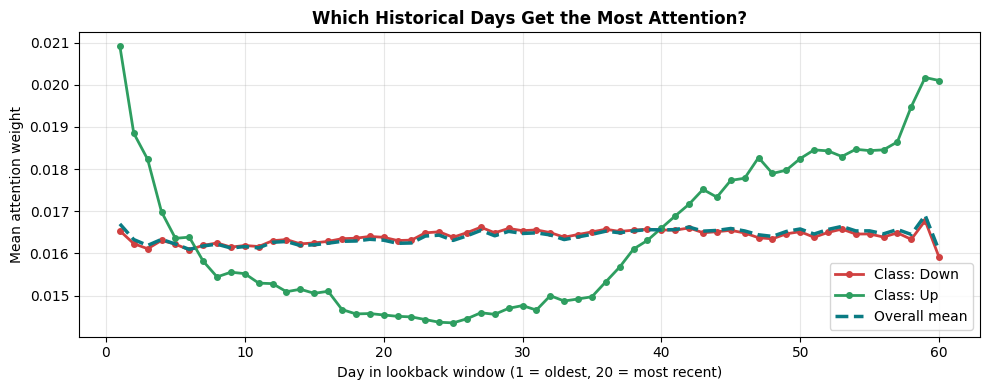


Attention interpretation guide:
  Peak at days 1-7  -> model attends to older regime signals
  Peak at days 14-20 -> momentum-driven, recency bias
  Different class patterns -> attention is regime-discriminative
  Uniform pattern -> attention adds global context only
  (All outcomes are scientifically valid -- report honestly)


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — ATTENTION WEIGHT VISUALIZATION                        ║
# ╚══════════════════════════════════════════════════════════════════╝

CLASS_NAMES_VIZ = ['Down', 'Neutral', 'Up']
last_fold    = FOLDS[-1]
trained_prop = last_fold.get('trained_proposed')

if trained_prop is None:
    print('No trained proposed model found. Run Cell 8 first.')
else:
    trained_prop.eval()
    X_te     = torch.tensor(last_fold['X_test']).to(DEVICE)
    y_pred_l = ALL_RESULTS['Proposed (CNN+Attn)'][-1]['y_pred']

    with torch.no_grad():
        _ = trained_prop(X_te, return_attn=True)
    attn_all = trained_prop._attn_weights   # (N_test, T, T)

    if attn_all is None:
        print('Attention weights not captured.')
    else:
        # Plot 1: Mean attention heatmap by class
        fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
        fig.suptitle(
            'Mean Attention Weights by Predicted Class\n'
            '(Rows=Query day, Cols=Key day, Brighter=More attended)',
            fontsize=12, fontweight='bold'
        )
        for cls_idx, cls_name in enumerate(CLASS_NAMES_VIZ):
            mask = y_pred_l == cls_idx
            ax   = axes[cls_idx]
            if mask.sum() == 0:
                ax.set_title(f'{cls_name}\n(no samples)')
                continue
            mean_attn = attn_all[mask].mean(axis=0)
            im = ax.imshow(mean_attn, cmap='viridis', aspect='auto', vmin=0)
            ax.set_title(f'Class: {cls_name}\n(n={mask.sum()} samples)', fontsize=11)
            ax.set_xlabel('Key (day in lookback)')
            ax.set_ylabel('Query (day in lookback)')
            plt.colorbar(im, ax=ax, fraction=0.046)
        plt.tight_layout()
        plt.savefig('attention_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show()

        # Plot 2: Per-class mean attention per time step
        fig, ax = plt.subplots(figsize=(10, 4))
        CLASS_COLORS = ['#D04040', '#888888', '#2E9E60']
        for cls_idx, (cls_name, col) in enumerate(zip(CLASS_NAMES_VIZ, CLASS_COLORS)):
            mask = y_pred_l == cls_idx
            if mask.sum() == 0:
                continue
            cls_attn = attn_all[mask].mean(axis=(0, 1))
            ax.plot(range(1, LOOKBACK + 1), cls_attn,
                    label=f'Class: {cls_name}', color=col,
                    linewidth=2, marker='o', markersize=4)
        overall = attn_all.mean(axis=(0, 1))
        ax.plot(range(1, LOOKBACK + 1), overall,
                label='Overall mean', color='#0A7B83',
                linewidth=2.5, linestyle='--')
        ax.set_xlabel('Day in lookback window (1 = oldest, 20 = most recent)')
        ax.set_ylabel('Mean attention weight')
        ax.set_title('Which Historical Days Get the Most Attention?', fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig('attention_by_day.png', dpi=150, bbox_inches='tight')
        plt.show()

        print('\nAttention interpretation guide:')
        print('  Peak at days 1-7  -> model attends to older regime signals')
        print('  Peak at days 14-20 -> momentum-driven, recency bias')
        print('  Different class patterns -> attention is regime-discriminative')
        print('  Uniform pattern -> attention adds global context only')
        print('  (All outcomes are scientifically valid -- report honestly)')


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — SAVE RESULTS TO GOOGLE DRIVE (OPTIONAL)               ║
# ╚══════════════════════════════════════════════════════════════════╝

SAVE_TO_DRIVE = False   # set True to enable

if SAVE_TO_DRIVE:
    from google.colab import drive
    import shutil, os
    drive.mount('/content/drive')
    OUT = '/content/drive/MyDrive/ML_Project_Results'
    os.makedirs(OUT, exist_ok=True)
    df_results = pd.DataFrame(summary_rows)
    df_results.to_csv(f'{OUT}/results_summary.csv', index=False)
    for fname in ['confusion_matrices.png', 'fold_comparison.png',
                  'summary_bars.png', 'attention_heatmap.png',
                  'attention_by_day.png']:
        src = f'/content/{fname}'
        if os.path.exists(src):
            shutil.copy(src, f'{OUT}/{fname}')
            print(f'  Saved: {fname}')
    print(f'All results saved to {OUT}')
else:
    print('SAVE_TO_DRIVE = False')
    print('Files in /content/ -> right-click -> Download in the Files panel.')
